In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
)

print("Model loaded")

Model loaded


In [ ]:
for layer in model.layers[0].layers[-20:]:
    print(layer.name)

block12_sepconv3_act
block12_sepconv3
block12_sepconv3_bn
add_10
block13_sepconv1_act
block13_sepconv1
block13_sepconv1_bn
block13_sepconv2_act
block13_sepconv2
block13_sepconv2_bn
conv2d_3
block13_pool
batch_normalization_3
add_11
block14_sepconv1
block14_sepconv1_bn
block14_sepconv1_act
block14_sepconv2
block14_sepconv2_bn
block14_sepconv2_act


In [ ]:
import zipfile
import random

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    files = [f for f in z.namelist() if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print("Total images in ZIP:", len(files))

for f in random.sample(files, 20):
    print(f)

Total images in ZIP: 140000
real-vs-fake/train/fake/0DX3Q0WDIG.jpg
real-vs-fake/train/real/56240.jpg
real-vs-fake/valid/fake/NW9MBPSBHE.jpg
real-vs-fake/train/fake/OQ5NIE1JT7.jpg
real-vs-fake/test/fake/U0XM7IU75V.jpg
real-vs-fake/train/fake/0DL8HHH4MP.jpg
real-vs-fake/train/real/46837.jpg
real-vs-fake/train/real/33792.jpg
real-vs-fake/train/fake/XTJZ8SV6T2.jpg
real-vs-fake/train/real/03656.jpg
real-vs-fake/train/fake/AT2PXLB9HW.jpg
real-vs-fake/train/real/38716.jpg
real-vs-fake/train/fake/R4WUUSHI7W.jpg
real-vs-fake/train/fake/G7K96KP9T0.jpg
real-vs-fake/test/fake/EP0C8S5GY1.jpg
real-vs-fake/train/fake/ITPKF0HKFH.jpg
real-vs-fake/train/real/26380.jpg
real-vs-fake/valid/real/54305.jpg
real-vs-fake/train/fake/IT3EDNKQJV.jpg
real-vs-fake/train/real/13921.jpg


In [ ]:
import zipfile
import random
import os

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

with zipfile.ZipFile(zip_path, 'r') as z:

    fake_files = [
        f for f in z.namelist()
        if "test/fake/" in f and f.lower().endswith(".jpg")
    ]

    real_files = [
        f for f in z.namelist()
        if "test/real/" in f and f.lower().endswith(".jpg")
    ]

    fake_img = random.choice(fake_files)
    real_img = random.choice(real_files)

    z.extract(fake_img, "/content/sample_images")
    z.extract(real_img, "/content/sample_images")

print("Fake:", fake_img)
print("Real:", real_img)

Fake: real-vs-fake/test/fake/RFQJ650615.jpg
Real: real-vs-fake/test/real/45188.jpg


FileNotFoundError: [Errno 2] No such file or directory: 'real-vs-fake/test/fake/RFQJ650615.jpgreal-vs-fake/test/fake/RFQJ650615.jpg'

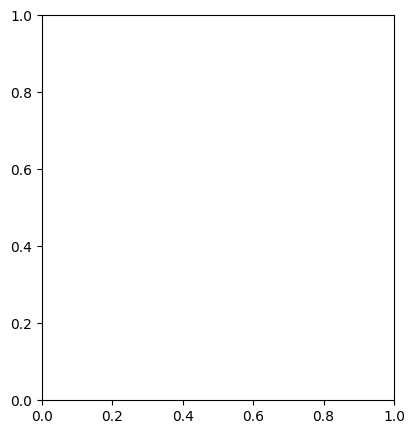

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fake_path = "real-vs-fake/test/fake/RFQJ650615.jpg" + fake_img
real_path = "real-vs-fake/test/real/45188.jpg" + real_img

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(Image.open(fake_path))
plt.title("Fake")

plt.subplot(1,2,2)
plt.imshow(Image.open(real_path))
plt.title("Real")

plt.show()

In [ ]:
fake_path = "/content/sample_images/" + fake_img
real_path = "/content/sample_images/" + real_img

print(fake_path)
print(real_path)

/content/sample_images/real-vs-fake/test/fake/RFQJ650615.jpg
/content/sample_images/real-vs-fake/test/real/45188.jpg


In [ ]:
import os

print("Fake exists:", os.path.exists(fake_path))
print("Real exists:", os.path.exists(real_path))

Fake exists: False
Real exists: False


In [ ]:
import os

for root, dirs, files in os.walk("/content/sample_images"):
    for f in files[:20]:
        print(os.path.join(root, f))

/content/sample_images/real-vs-fake/test/real/45188.jpg
/content/sample_images/real-vs-fake/test/fake/RFQJ650615.jpg


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fake_img_display = Image.open(fake_path)
real_img_display = Image.open(real_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(fake_img_display)
plt.title("Fake")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(real_img_display)
plt.title("Real")
plt.axis("off")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_images/real-vs-fake/test/fake/RFQJ650615.jpgreal-vs-fake/test/fake/RFQJ650615.jpg'

In [ ]:
fake_path = "/content/sample_images/real-vs-fake/test/fake/RFQJ650615.jpg"
real_path = "/content/sample_images/real-vs-fake/test/real/45188.jpg"

print(fake_path)
print(real_path)

/content/sample_images/real-vs-fake/test/fake/RFQJ650615.jpg
/content/sample_images/real-vs-fake/test/real/45188.jpg


In [ ]:
import os

print(os.path.exists(fake_path))
print(os.path.exists(real_path))

True
True


In [ ]:
from PIL import Image

fake_img_display = Image.open(fake_path)
real_img_display = Image.open(real_path)

print(fake_img_display.size)
print(real_img_display.size)

(256, 256)
(256, 256)


In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

def predict_image(img_path):

    img = load_img(img_path, target_size=(299,299))
    img = img_to_array(img)

    x = np.expand_dims(img, axis=0)
    x = preprocess_input(x)

    pred = model.predict(x, verbose=0)[0][0]

    print("Raw prediction:", pred)

    if pred < 0.5:
        print("Prediction: FAKE")
        print("Confidence:", round((1-pred)*100,2), "%")
    else:
        print("Prediction: REAL")
        print("Confidence:", round(pred*100,2), "%")


print("===== FAKE IMAGE =====")
predict_image(fake_path)

print("\n===== REAL IMAGE =====")
predict_image(real_path)

===== FAKE IMAGE =====
Raw prediction: 0.034240037
Prediction: FAKE
Confidence: 96.58 %

===== REAL IMAGE =====
Raw prediction: 0.9999112
Prediction: REAL
Confidence: 99.99 %


In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

model_path = "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"

print(os.path.exists(model_path))

True


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(model_path)
print("Model loaded")

Model loaded


In [ ]:
import os

print(os.path.exists("/content/sample_images/real-vs-fake"))

False


In [ ]:
import os

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"
print(os.path.exists(zip_path))

True


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extract(
        "real-vs-fake/test/fake/RFQJ650615.jpg",
        "/content"
    )

print("Done")

Done


In [ ]:
import os

img_path = "/content/real-vs-fake/test/fake/RFQJ650615.jpg"

print(os.path.exists(img_path))

True


In [ ]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"

model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(img_path, target_size=(299,299))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = tf.keras.applications.xception.preprocess_input(x)

pred = model.predict(x, verbose=0)

print(pred[0][0])

0.034240037


In [ ]:
print(model.input_shape)
print(model.output_shape)

(None, 299, 299, 3)
(None, 1)


In [ ]:
import os

print(os.path.exists("/content/real-vs-fake/test/fake/RFQJ650615.jpg"))
print(os.path.exists("/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"))

True
True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"

print(os.path.exists(MODEL_PATH))

True


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/VeritasAI"):
    for f in files:
        if f.endswith(".zip"):
            print(os.path.join(root, f))

/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip


In [ ]:
import zipfile

ZIP_PATH = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extract(
        "real-vs-fake/test/fake/RFQJ650615.jpg",
        "/content"
    )

In [ ]:
import os

print(os.path.exists(
    "/content/real-vs-fake/test/fake/RFQJ650615.jpg"
))

True


In [ ]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block13_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)

    print("\n===== GRADIENT DEBUG =====")
    print("grads is None:", grads is None)

    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )

    print("grads min :", tf.reduce_min(grads).numpy())
    print("grads max :", tf.reduce_max(grads).numpy())
    print("grads mean:", tf.reduce_mean(grads).numpy())

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    print("\n===== POOLED GRADS =====")
    print("pooled min :", tf.reduce_min(pooled_grads).numpy())
    print("pooled max :", tf.reduce_max(pooled_grads).numpy())
    print("pooled mean:", tf.reduce_mean(pooled_grads).numpy())    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap = tf.squeeze(heatmap)

    print("\n===== RAW HEATMAP =====")
    print("raw min :", tf.reduce_min(heatmap).numpy())
    print("raw max :", tf.reduce_max(heatmap).numpy())
    print("raw mean:", tf.reduce_mean(heatmap).numpy())                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [ ]:
test_image = "/content/drive/MyDrive/VeritasAI/gradcam_results/pnas.2110013119fig01.jpg"

img_tensor, img_orig = preprocess_image(test_image)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block12_sepconv2_act"
)

print("\nFINAL PROBABILITY =", prob)
print("FINAL HEATMAP MIN =", heatmap.min())
print("FINAL HEATMAP MAX =", heatmap.max())
print("FINAL HEATMAP MEAN =", heatmap.mean())

[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -0.0010847271
grads max : 0.0018330908
grads mean: -2.1584074e-06

===== POOLED GRADS =====
pooled min : -0.00010796883
pooled max : 0.00010205405
pooled mean: -2.1584071e-06

===== RAW HEATMAP =====
raw min : -0.001166115
raw max : 0.00044844003
raw mean: -0.00017643996

FINAL PROBABILITY = 0.9679468870162964
FINAL HEATMAP MIN = 0.0
FINAL HEATMAP MAX = 0.99997765
FINAL HEATMAP MEAN = 0.08766179


In [ ]:
args = argparse.Namespace(
    image="/content/real-vs-fake/test/fake/RFQJ650615.jpg",
    model="/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras",
    layer="block14_sepconv2_act",
    threshold=0.5,
    alpha=0.45,
    output="/content/fake_gradcam.jpg",
    list_layers=False
)

In [ ]:
run(args)

[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers
[INFO] Processing image: /content/real-vs-fake/test/fake/RFQJ650615.jpg
[INFO] Running Grad-CAM on layer: 'block14_sepconv2_act'
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'

────────────────────────────────────────
  Prediction : FAKE
  Real prob  : 0.1438  (14.4%)
  Threshold  : 0.5
────────────────────────────────────────

[INFO] Visualization saved → /content/fake_gradcam.jpg


In [ ]:
import os

print(os.path.exists("/content/fake_gradcam.jpg"))

True


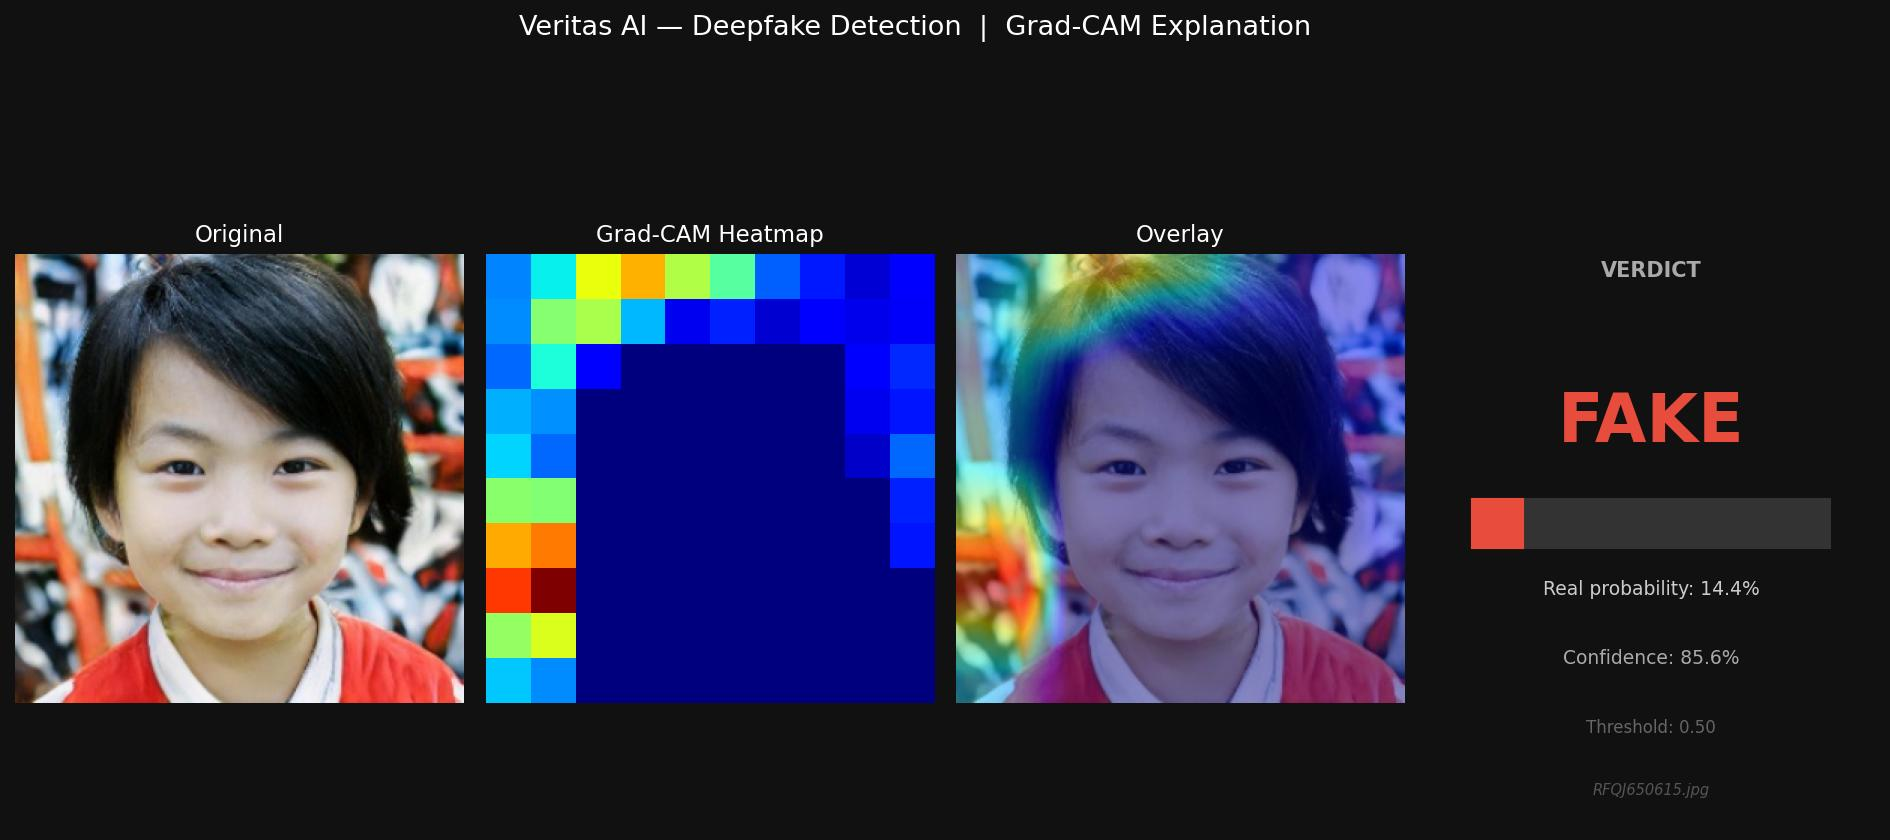

In [ ]:
from PIL import Image
from IPython.display import display

display(Image.open("/content/fake_gradcam.jpg"))

In [ ]:
img_tensor, _ = preprocess_image(
    "/content/real-vs-fake/test/fake/RFQJ650615.jpg"
)

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
)

print(model.predict(img_tensor))

1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step
[[0.14380656]]


In [ ]:
import zipfile
import random
import os

ZIP_PATH = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"  # adjust if needed

with zipfile.ZipFile(ZIP_PATH, 'r') as z:

    all_files = z.namelist()

    real_images = [
        f for f in all_files
        if "/real/" in f and f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    fake_images = [
        f for f in all_files
        if "/fake/" in f and f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random_real = random.sample(real_images, 5)
    random_fake = random.sample(fake_images, 5)

    selected = random_real + random_fake

    output_dir = "/content/gradcam_samples"
    os.makedirs(output_dir, exist_ok=True)

    for file in selected:
        z.extract(file, output_dir)

print("===== RANDOM REAL IMAGES =====")
for img in random_real:
    print(img)

print("\n===== RANDOM FAKE IMAGES =====")
for img in random_fake:
    print(img)

print("\nExtracted to:")
print(output_dir)

===== RANDOM REAL IMAGES =====
real-vs-fake/train/real/33217.jpg
real-vs-fake/train/real/64046.jpg
real-vs-fake/valid/real/51436.jpg
real-vs-fake/test/real/06017.jpg
real-vs-fake/train/real/04365.jpg

===== RANDOM FAKE IMAGES =====
real-vs-fake/train/fake/9KIS7QRBID.jpg
real-vs-fake/train/fake/43PMHNO2PB.jpg
real-vs-fake/train/fake/R2U03OOP1P.jpg
real-vs-fake/train/fake/0RENCZP74L.jpg
real-vs-fake/train/fake/JSVBD52Q0V.jpg

Extracted to:
/content/gradcam_samples


In [ ]:
import os

image_paths = []

for root, dirs, files in os.walk("/content/gradcam_samples"):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, f))

print(f"Found {len(image_paths)} images")

for p in image_paths:
    print(p)

Found 10 images
/content/gradcam_samples/real-vs-fake/valid/real/51436.jpg
/content/gradcam_samples/real-vs-fake/test/real/06017.jpg
/content/gradcam_samples/real-vs-fake/train/real/64046.jpg
/content/gradcam_samples/real-vs-fake/train/real/04365.jpg
/content/gradcam_samples/real-vs-fake/train/real/33217.jpg
/content/gradcam_samples/real-vs-fake/train/fake/JSVBD52Q0V.jpg
/content/gradcam_samples/real-vs-fake/train/fake/9KIS7QRBID.jpg
/content/gradcam_samples/real-vs-fake/train/fake/0RENCZP74L.jpg
/content/gradcam_samples/real-vs-fake/train/fake/43PMHNO2PB.jpg
/content/gradcam_samples/real-vs-fake/train/fake/R2U03OOP1P.jpg


In [ ]:
import os

os.makedirs("/content/gradcam_results", exist_ok=True)

for img_path in image_paths:

    output_file = os.path.join(
        "/content/gradcam_results",
        os.path.basename(img_path).replace(".jpg", "_gradcam.jpg")
    )

    args = argparse.Namespace(
        image=img_path,
        model="/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras",
        layer="block14_sepconv2_act",
        threshold=0.5,
        alpha=0.45,
        output=output_file,
        list_layers=False
    )

    print(f"\nProcessing: {os.path.basename(img_path)}")

    try:
        run(args)
    except Exception as e:
        print("ERROR:", e)


Processing: 51436.jpg
[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers
[INFO] Processing image: /content/gradcam_samples/real-vs-fake/valid/real/51436.jpg
[INFO] Running Grad-CAM on layer: 'block14_sepconv2_act'
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'

────────────────────────────────────────
  Prediction : REAL
  Real prob  : 0.9953  (99.5%)
  Threshold  : 0.5
────────────────────────────────────────

[INFO] Visualization saved → /content/gradcam_results/51436_gradcam.jpg

Processing: 06017.jpg
[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers
[INFO] Processing image: /content/gradcam_samples/real-vs-fake/test/real/06017.jpg
[INFO] Running Grad-CAM on layer: 'block14_sepconv2_act'
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'

────────

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

results = sorted([
    os.path.join("/content/gradcam_results", f)
    for f in os.listdir("/content/gradcam_results")
])

plt.figure(figsize=(20, 30))

for i, img in enumerate(results):
    plt.subplot(len(results), 1, i + 1)
    plt.imshow(Image.open(img))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

files = os.listdir("/content/gradcam_results")

print("Number of files:", len(files))

for f in files:
    print(f)

Number of files: 10
43PMHNO2PB_gradcam.jpg
06017_gradcam.jpg
R2U03OOP1P_gradcam.jpg
64046_gradcam.jpg
51436_gradcam.jpg
JSVBD52Q0V_gradcam.jpg
33217_gradcam.jpg
04365_gradcam.jpg
9KIS7QRBID_gradcam.jpg
0RENCZP74L_gradcam.jpg


['04365_gradcam.jpg', '06017_gradcam.jpg', '0RENCZP74L_gradcam.jpg', '33217_gradcam.jpg', '43PMHNO2PB_gradcam.jpg', '51436_gradcam.jpg', '64046_gradcam.jpg', '9KIS7QRBID_gradcam.jpg', 'JSVBD52Q0V_gradcam.jpg', 'R2U03OOP1P_gradcam.jpg']


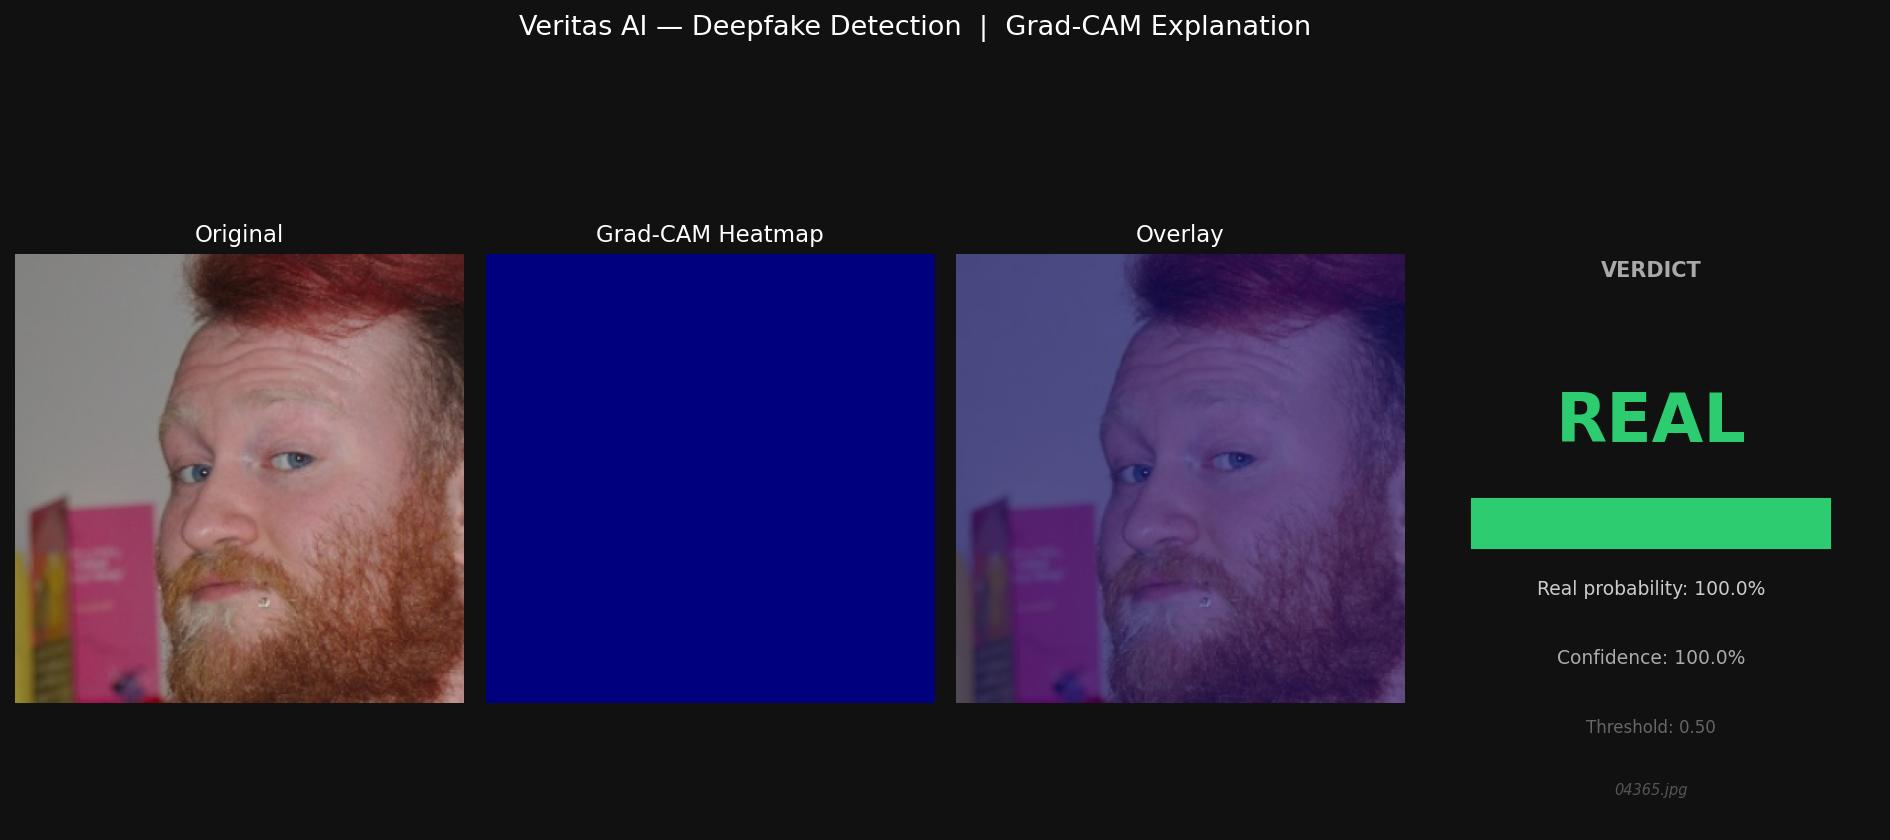

In [ ]:
from PIL import Image
from IPython.display import display
import os

files = sorted(os.listdir("/content/gradcam_results"))

print(files)

display(Image.open(
    os.path.join("/content/gradcam_results", files[0])
))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

files = sorted(os.listdir("/content/gradcam_results"))

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for ax, f in zip(axes.ravel(), files):
    img = Image.open(os.path.join("/content/gradcam_results", f))
    ax.imshow(img)
    ax.set_title(f[:15], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
from IPython.display import display
import os

files = sorted(os.listdir("/content/gradcam_results"))

for f in files:
    print("\n", f)
    display(Image.open(os.path.join("/content/gradcam_results", f)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

model_path = "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"

print(os.path.exists(model_path))

True


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/VeritasAI"):
    for f in files:
        if f.endswith(".zip"):
            print(os.path.join(root, f))

/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip


In [ ]:
import zipfile
import random
import os

ZIP_PATH = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

extract_dir = "/content/gradcam_samples"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    real_images = [
        f for f in z.namelist()
        if "/real/" in f and f.lower().endswith(".jpg")
    ]

    fake_images = [
        f for f in z.namelist()
        if "/fake/" in f and f.lower().endswith(".jpg")
    ]

    selected_real = random.sample(real_images, 25)
    selected_fake = random.sample(fake_images, 25)

    for file in selected_real + selected_fake:
        z.extract(file, extract_dir)

print("25 real + 25 fake extracted")

25 real + 25 fake extracted


In [ ]:
import os

image_paths = []

for root, dirs, files in os.walk("/content/gradcam_samples"):
    for f in files:
        if f.lower().endswith(".jpg"):
            image_paths.append(os.path.join(root, f))

print("Total images:", len(image_paths))

Total images: 50


In [ ]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block14_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)
    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )   # [1, h, w, C]

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap      = tf.squeeze(heatmap)                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [ ]:
model = load_model(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
)

[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers


In [ ]:
import os

RESULTS_DIR = "/content/drive/MyDrive/VeritasAI/gradcam_results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results folder ready")

Results folder ready


In [ ]:
for img_path in image_paths:

    print("Processing:", os.path.basename(img_path))

    img_tensor, img_orig = preprocess_image(img_path)

    heatmap, prob = compute_gradcam(
        model,
        img_tensor,
        "block14_sepconv2_act"
    )

    blended = overlay_heatmap(
        heatmap,
        img_orig,
        alpha=0.45
    )

    output_path = os.path.join(
        RESULTS_DIR,
        os.path.basename(img_path).replace(".jpg", "_gradcam.jpg")
    )

    build_visualization(
        orig_img=img_orig,
        blended=blended,
        heatmap=heatmap,
        prob=prob,
        threshold=0.5,
        image_path=img_path,
        output_path=output_path
    )

print("DONE")

Processing: 69653.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_results/69653_gradcam.jpg
Processing: 09836.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_results/09836_gradcam.jpg
Processing: 49448.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_results/49448_gradcam.jpg
Processing: N2Y18CMEQL.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_results/N2Y18CMEQL_gradcam.jpg
Processing: JJAXF7HZTW.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_results/JJAXF7HZTW_gradcam.jpg
Processing: 7LM6EM9M

In [ ]:
import os

files = os.listdir(
    "/content/drive/MyDrive/VeritasAI/gradcam_results"
)

print("Generated:", len(files))

Generated: 50


In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

files = os.listdir(
    "/content/drive/MyDrive/VeritasAI/gradcam_results"
)

sample = random.sample(files, 9)

fig, axes = plt.subplots(3,3, figsize=(18,18))

for ax, f in zip(axes.ravel(), sample):

    img = Image.open(
        os.path.join(
            "/content/drive/MyDrive/VeritasAI/gradcam_results",
            f
        )
    )

    ax.imshow(img)
    ax.axis("off")

plt.show()

In [ ]:
import os

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_results"

files = os.listdir(results_dir)

print("Number of files:", len(files))

for f in files[:10]:
    print(f)

Number of files: 50
69653_gradcam.jpg
09836_gradcam.jpg
49448_gradcam.jpg
N2Y18CMEQL_gradcam.jpg
JJAXF7HZTW_gradcam.jpg
7LM6EM9MLF_gradcam.jpg
G8KGRW5IRZ_gradcam.jpg
013O4R3GO3_gradcam.jpg
62999_gradcam.jpg
10637_gradcam.jpg


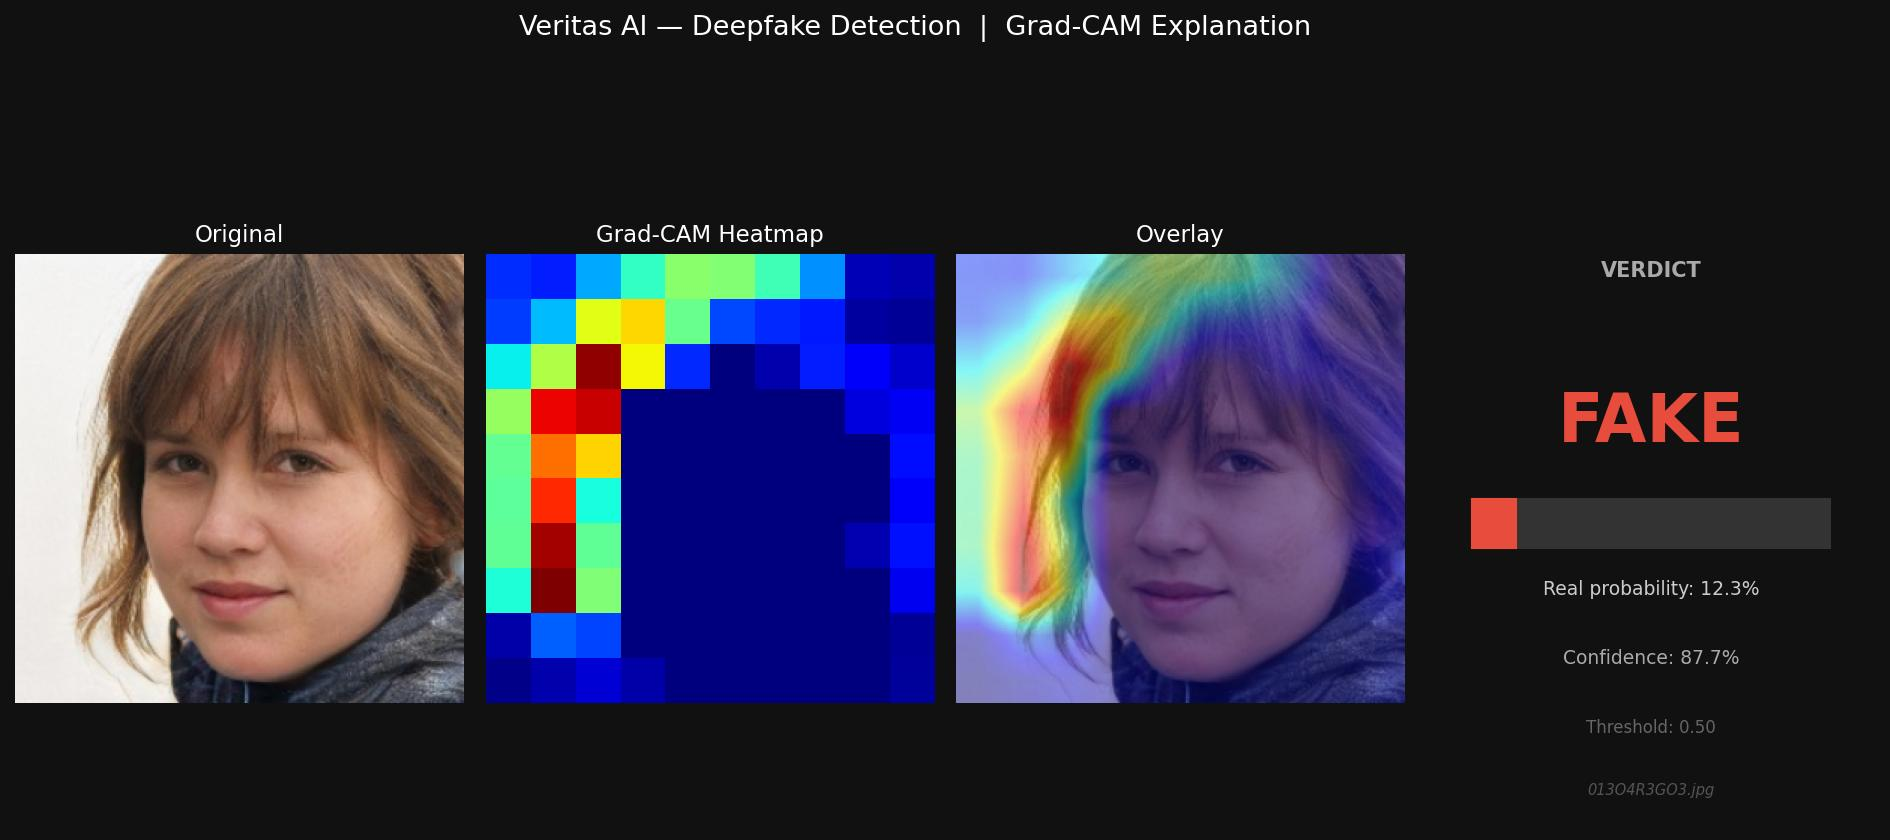

In [ ]:
from PIL import Image
from IPython.display import display
import os

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_results"

files = sorted(os.listdir(results_dir))

display(Image.open(os.path.join(results_dir, files[0])))

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_results"

files = os.listdir(results_dir)

sample = random.sample(files, 9)

for f in sample:
    img = Image.open(os.path.join(results_dir, f))

    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.title(f)
    plt.axis("off")
    plt.show()

In [ ]:
from PIL import Image
import os

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_results"

files = os.listdir(results_dir)

img_path = os.path.join(results_dir, files[0])

print(img_path)

img = Image.open(img_path)

print("Format:", img.format)
print("Size:", img.size)
print("Mode:", img.mode)

/content/drive/MyDrive/VeritasAI/gradcam_results/69653_gradcam.jpg
Format: JPEG
Size: (1890, 840)
Mode: RGB


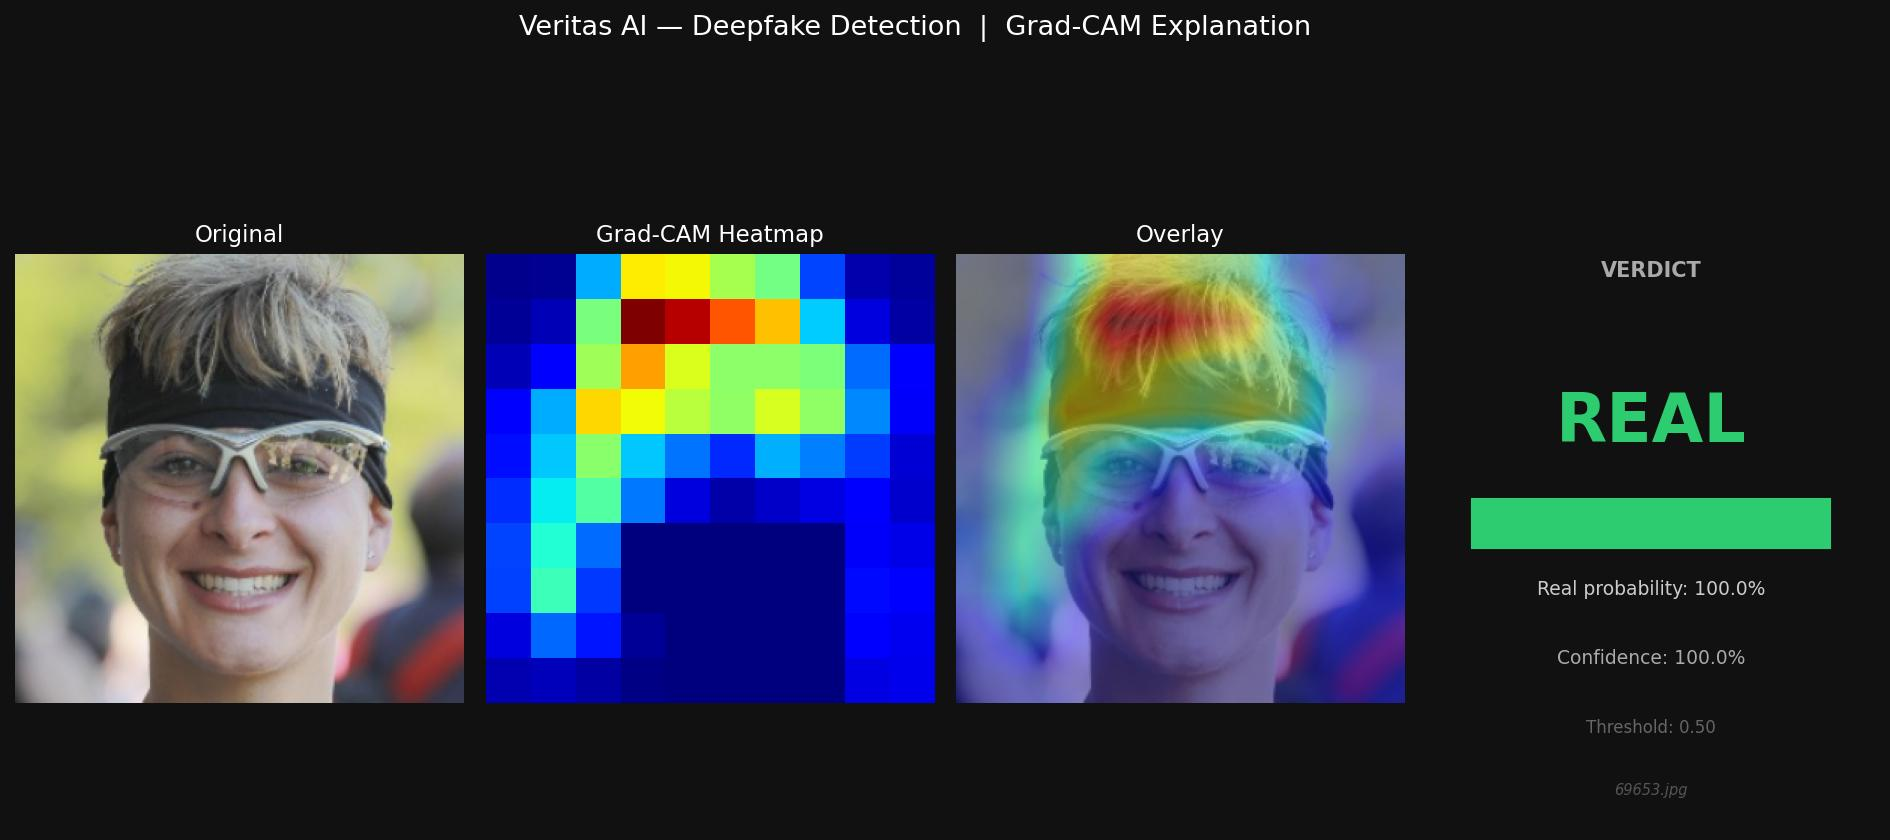

In [ ]:
from IPython.display import Image as IPImage, display
import os

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_results"

files = os.listdir(results_dir)

display(IPImage(os.path.join(results_dir, files[0])))

In [ ]:
import os

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_results"

for f in os.listdir(results_dir)[:10]:
    path = os.path.join(results_dir, f)
    print(f, os.path.getsize(path))

69653_gradcam.jpg 91558
09836_gradcam.jpg 94622
49448_gradcam.jpg 103922
N2Y18CMEQL_gradcam.jpg 85956
JJAXF7HZTW_gradcam.jpg 85825
7LM6EM9MLF_gradcam.jpg 88137
G8KGRW5IRZ_gradcam.jpg 82935
013O4R3GO3_gradcam.jpg 93899
62999_gradcam.jpg 95681
10637_gradcam.jpg 96012


In [ ]:
from PIL import Image
from IPython.display import display
import os

files = sorted(os.listdir("/content/drive/MyDrive/VeritasAI/gradcam_results"))

for f in files:
    print("\n", f)
    display(Image.open(os.path.join("/content/drive/MyDrive/VeritasAI/gradcam_results", f)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os

for f in os.listdir("/content/gradcam_samples/real-vs-fake/test/fake"):
    print(f)

HOMH6R7UYJ.jpg
9U1RFUU7KK.jpg
SE21VOXX35.jpg
N7NCWM6HMT.jpg
BMJSROGR5A.jpg


In [ ]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block13_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)
    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )   # [1, h, w, C]

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap      = tf.squeeze(heatmap)                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [ ]:
model = load_model("/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras")

[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers


In [ ]:
import os

for root, dirs, files in os.walk("/content/gradcam_samples"):
    for f in files:
        print(os.path.join(root, f))

/content/gradcam_samples/real-vs-fake/valid/real/69653.jpg
/content/gradcam_samples/real-vs-fake/valid/real/09836.jpg
/content/gradcam_samples/real-vs-fake/valid/real/49448.jpg
/content/gradcam_samples/real-vs-fake/valid/fake/N2Y18CMEQL.jpg
/content/gradcam_samples/real-vs-fake/valid/fake/JJAXF7HZTW.jpg
/content/gradcam_samples/real-vs-fake/valid/fake/7LM6EM9MLF.jpg
/content/gradcam_samples/real-vs-fake/valid/fake/G8KGRW5IRZ.jpg
/content/gradcam_samples/real-vs-fake/valid/fake/013O4R3GO3.jpg
/content/gradcam_samples/real-vs-fake/test/real/62999.jpg
/content/gradcam_samples/real-vs-fake/test/real/10637.jpg
/content/gradcam_samples/real-vs-fake/test/real/04567.jpg
/content/gradcam_samples/real-vs-fake/test/real/32252.jpg
/content/gradcam_samples/real-vs-fake/test/fake/HOMH6R7UYJ.jpg
/content/gradcam_samples/real-vs-fake/test/fake/9U1RFUU7KK.jpg
/content/gradcam_samples/real-vs-fake/test/fake/SE21VOXX35.jpg
/content/gradcam_samples/real-vs-fake/test/fake/N7NCWM6HMT.jpg
/content/gradcam_sa

In [ ]:
fake_img = "/content/drive/MyDrive/VeritasAI/gradcam_results/pnas.2110013119fig01.jpg"
real_img = "/content/gradcam_samples/real-vs-fake/train/real/48293.jpg"

In [ ]:
img_tensor, img_orig = preprocess_image(fake_img)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    LAST_CONV_LAYER
)

overlay = overlay_heatmap(heatmap, img_orig)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

print("Probability =", prob)

[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
Probability = 0.9679468870162964


In [ ]:
img_tensor, img_orig = preprocess_image(real_img)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    LAST_CONV_LAYER
)

overlay = overlay_heatmap(heatmap, img_orig)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

print("Probability =", prob)

[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
Probability = 1.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.path.exists(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
))

True


In [ ]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block13_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)
    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )   # [1, h, w, C]

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap      = tf.squeeze(heatmap)                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [ ]:
model = load_model(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
)

[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers


In [ ]:
img_path = "/content/drive/MyDrive/VeritasAI/gradcam_results/pnas.2110013119fig01.jpg"

In [ ]:
img_tensor, img_orig = preprocess_image(img_path)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    LAST_CONV_LAYER
)

overlay = overlay_heatmap(heatmap, img_orig)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

print("Probability =", prob)

[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
Probability = 0.9679468870162964


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

In [ ]:
print(type(overlay))

<class 'numpy.ndarray'>


In [ ]:
print(overlay.shape)

(299, 299, 3)


In [ ]:
print(overlay.min(), overlay.max())

3 255


In [ ]:
from PIL import Image

Image.fromarray(overlay).save("/content/test_gradcam.jpg")

print("Saved!")

Saved!


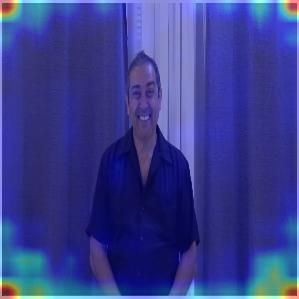

In [ ]:
from PIL import Image
Image.open("/content/test_gradcam.jpg")

In [ ]:
import os

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

print(os.path.exists(zip_path))

True


In [ ]:
import zipfile
import random
import os
import shutil

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

extract_dir = "/content/gradcam_100"

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:

    all_files = z.namelist()

    real_files = [
        f for f in all_files
        if "/real/" in f and f.endswith(".jpg")
    ]

    fake_files = [
        f for f in all_files
        if "/fake/" in f and f.endswith(".jpg")
    ]

    selected_real = random.sample(real_files, 50)
    selected_fake = random.sample(fake_files, 50)

    for f in selected_real + selected_fake:
        z.extract(f, extract_dir)

print("Real images:", len(selected_real))
print("Fake images:", len(selected_fake))
print("Done")

Real images: 50
Fake images: 50
Done


In [ ]:
import os

count = 0

for root, dirs, files in os.walk("/content/gradcam_100"):
    count += len(files)

print("Extracted files:", count)

Extracted files: 100


In [ ]:
model = load_model(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
)

[INFO] Loading model from /content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras …
[INFO] Model loaded — 6 top-level layers


In [ ]:
import os

for root, dirs, files in os.walk("/content/gradcam_100"):
    if len(files) > 0:
        test_image = os.path.join(root, files[0])
        break

print(test_image)

/content/gradcam_100/real-vs-fake/valid/real/21521.jpg


In [ ]:
img_tensor, img_orig = preprocess_image(test_image)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block13_sepconv2_act"
)

overlay = overlay_heatmap(
    heatmap,
    img_orig
)

print("Probability =", prob)

[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
Probability = 1.0


In [ ]:
import os

output_dir = "/content/drive/MyDrive/VeritasAI/gradcam_100_results"

os.makedirs(output_dir, exist_ok=True)

print(output_dir)

/content/drive/MyDrive/VeritasAI/gradcam_100_results


In [ ]:
import os
from pathlib import Path

processed = 0

for root, dirs, files in os.walk("/content/gradcam_100"):

    for file in files:

        if not file.lower().endswith(".jpg"):
            continue

        image_path = os.path.join(root, file)

        try:

            img_tensor, img_orig = preprocess_image(image_path)

            heatmap, prob = compute_gradcam(
                model,
                img_tensor,
                "block13_sepconv2_act"
            )

            overlay = overlay_heatmap(
                heatmap,
                img_orig
            )

            output_path = os.path.join(
                output_dir,
                Path(file).stem + "_gradcam.jpg"
            )

            build_visualization(
                orig_img=img_orig,
                blended=overlay,
                heatmap=heatmap,
                prob=prob,
                threshold=0.5,
                image_path=image_path,
                output_path=output_path
            )

            processed += 1

            if processed % 10 == 0:
                print(f"Processed {processed}")

        except Exception as e:
            print(f"Error on {file}: {e}")

print("\nFinished")
print("Total processed:", processed)

[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_100_results/21521_gradcam.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_100_results/03388_gradcam.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_100_results/22218_gradcam.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_100_results/42671_gradcam.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/VeritasAI/gradcam_100_results/54946_gradcam.jpg
[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
[INFO] Visualization saved → /content/drive/MyDrive/Veri

In [ ]:
import os

files = os.listdir(output_dir)

print("Generated:", len(files))

Generated: 100


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

files = random.sample(os.listdir(output_dir), 16)

plt.figure(figsize=(16,16))

for i, f in enumerate(files):

    img = Image.open(os.path.join(output_dir, f))

    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(f[:12], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

files = random.sample(os.listdir(output_dir), 16)

plt.figure(figsize=(16,16))

for i, f in enumerate(files):

    img = Image.open(os.path.join(output_dir, f))

    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(f[:12], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

output_dir = "/content/drive/MyDrive/VeritasAI/gradcam_100_results"

files = os.listdir(output_dir)

print("Number of files:", len(files))

for f in files[:5]:
    print(f)

Number of files: 100
21521_gradcam.jpg
03388_gradcam.jpg
22218_gradcam.jpg
42671_gradcam.jpg
54946_gradcam.jpg


DV1LTV4FTQ_gradcam.jpg


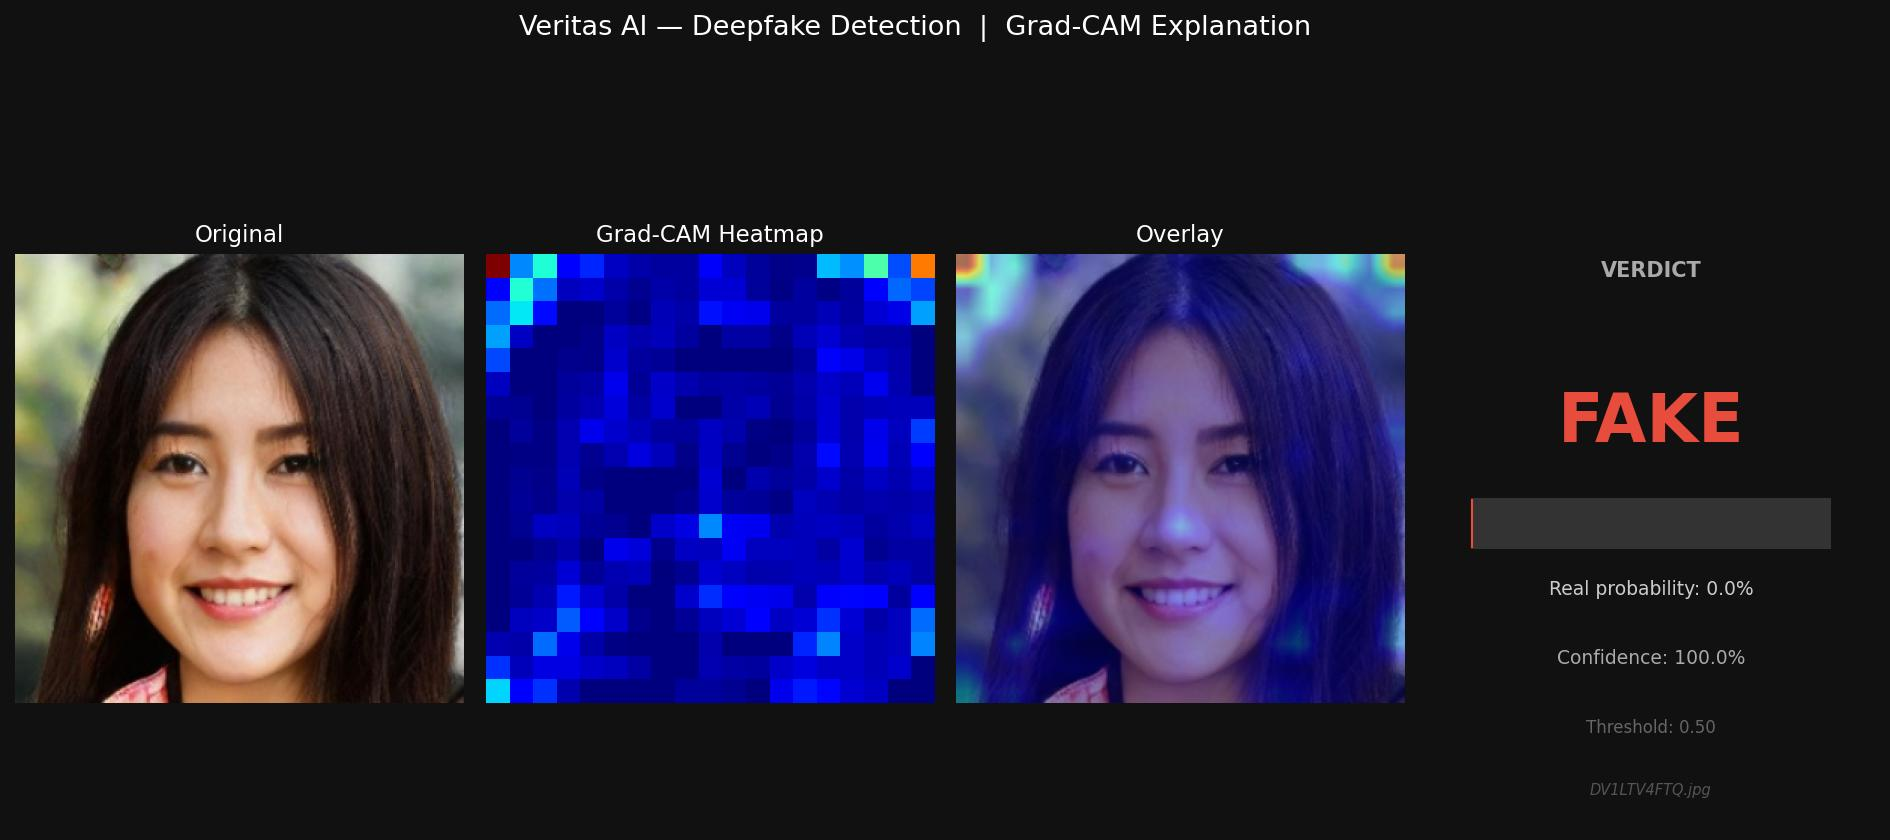

In [ ]:
from PIL import Image
import random
import os

output_dir = "/content/drive/MyDrive/VeritasAI/gradcam_100_results"

file = random.choice(os.listdir(output_dir))

print(file)

img = Image.open(os.path.join(output_dir, file))

img

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

results_dir = "/content/drive/MyDrive/VeritasAI/gradcam_100_results"

files = random.sample(os.listdir(results_dir), 10)

for i, f in enumerate(files):

    img_path = os.path.join(results_dir, f)

    img = Image.open(img_path)

    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.title(f"{i+1}/10 : {f}")
    plt.axis("off")
    plt.show()

    print("="*60)

In [ ]:
from PIL import Image
import random
import os
from IPython.display import display

output_dir = "/content/drive/MyDrive/VeritasAI/gradcam_100_results"

files = random.sample(os.listdir(output_dir), 10)

for i, file in enumerate(files):

    print(f"\nImage {i+1}/10")
    print(file)

    img = Image.open(os.path.join(output_dir, file))

    display(img)

    print("="*60)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block12_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)
    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )   # [1, h, w, C]

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap      = tf.squeeze(heatmap)                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [ ]:
img_tensor, img_orig = preprocess_image(test_image)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block12_sepconv2_act"
)

overlay = overlay_heatmap(
    heatmap,
    img_orig
)

from PIL import Image
import matplotlib.pyplot as plt

plt.imshow(overlay)
plt.axis("off")
plt.show()

[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'


In [ ]:
print(type(overlay))
print(overlay.shape)

<class 'numpy.ndarray'>
(299, 299, 3)


In [ ]:
print(type(overlay))
print(overlay.shape)

<class 'numpy.ndarray'>
(299, 299, 3)


In [ ]:
print("Probability =", prob)

print("Heatmap min =", heatmap.min())
print("Heatmap max =", heatmap.max())
print("Heatmap mean =", heatmap.mean())

Probability = 1.0
Heatmap min = 0.0
Heatmap max = 0.0
Heatmap mean = 0.0


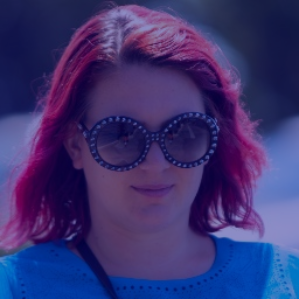

In [ ]:
from PIL import Image

Image.fromarray(overlay)

In [ ]:
heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block13_sepconv2_act"
)

print("Probability =", prob)
print("Heatmap min =", heatmap.min())
print("Heatmap max =", heatmap.max())
print("Heatmap mean =", heatmap.mean())

[INFO] Conv target found in sub-model (layers[0]): 'block13_sepconv2_act'
Probability = 1.0
Heatmap min = 0.0
Heatmap max = 0.0
Heatmap mean = 0.0


In [ ]:
heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block14_sepconv2_act"
)

print("Probability =", prob)
print("Heatmap min =", heatmap.min())
print("Heatmap max =", heatmap.max())
print("Heatmap mean =", heatmap.mean())

[INFO] Conv target found in sub-model (layers[0]): 'block14_sepconv2_act'
Probability = 1.0
Heatmap min = 0.0
Heatmap max = 0.0
Heatmap mean = 0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

model_path = "/content/drive/MyDrive/VeritasAI/veritas_xception_v2_finetuned.keras"

print(os.path.exists(model_path))

False


In [ ]:
import os

base = "/content/drive/MyDrive"

for root, dirs, files in os.walk(base):
    for file in files:
        if file.endswith(".keras"):
            print(os.path.join(root, file))

/content/drive/MyDrive/VeritasAI/models/veritas_xception_v1.keras
/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras


In [ ]:
import os

model_path = "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"

print(os.path.exists(model_path))

True


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(model_path)

print("Loaded successfully")

Loaded successfully


In [ ]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,529,389 (150.79 MB)

 Trainable params: 9,202,753 (35.11 MB)

 Non-trainable params: 11,921,128 (45.48 MB)

 Optimizer params: 18,405,508 (70.21 MB)

None


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/VeritasAI"):
    for f in files:
        if f.endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, f))

/content/drive/MyDrive/VeritasAI/gradcam_results/69653_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/09836_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/49448_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/N2Y18CMEQL_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/JJAXF7HZTW_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/7LM6EM9MLF_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/G8KGRW5IRZ_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/013O4R3GO3_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/62999_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/10637_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/04567_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/32252_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/HOMH6R7UYJ_gradcam.jpg
/content/drive/MyDrive/VeritasAI/gradcam_results/9U1RFUU7KK_gradcam.jpg
/content/drive/MyDrive/Veri

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/VeritasAI"):
    for f in files:
        if (
            f.endswith((".jpg", ".jpeg", ".png"))
            and "_gradcam" not in f
        ):
            print(os.path.join(root, f))

/content/drive/MyDrive/VeritasAI/gradcam_results/pnas.2110013119fig01.jpg


In [ ]:
print(preprocess_image)

NameError: name 'preprocess_image' is not defined

In [ ]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block12_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)

    print("\n===== GRADIENT DEBUG =====")
    print("grads is None:", grads is None)

    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )

    print("grads min :", tf.reduce_min(grads).numpy())
    print("grads max :", tf.reduce_max(grads).numpy())
    print("grads mean:", tf.reduce_mean(grads).numpy())

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    print("\n===== POOLED GRADS =====")
    print("pooled min :", tf.reduce_min(pooled_grads).numpy())
    print("pooled max :", tf.reduce_max(pooled_grads).numpy())
    print("pooled mean:", tf.reduce_mean(pooled_grads).numpy())    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap = tf.squeeze(heatmap)

    print("\n===== RAW HEATMAP =====")
    print("raw min :", tf.reduce_min(heatmap).numpy())
    print("raw max :", tf.reduce_max(heatmap).numpy())
    print("raw mean:", tf.reduce_mean(heatmap).numpy())                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [ ]:
test_image = "/content/drive/MyDrive/VeritasAI/gradcam_results/pnas.2110013119fig01.jpg"

img_tensor, img_orig = preprocess_image(test_image)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block12_sepconv2_act"
)

print("\nFINAL PROBABILITY =", prob)
print("FINAL HEATMAP MIN =", heatmap.min())
print("FINAL HEATMAP MAX =", heatmap.max())
print("FINAL HEATMAP MEAN =", heatmap.mean())

[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -0.0010847271
grads max : 0.0018330908
grads mean: -2.1584074e-06

===== POOLED GRADS =====
pooled min : -0.00010796883
pooled max : 0.00010205405
pooled mean: -2.1584071e-06

===== RAW HEATMAP =====
raw min : -0.001166115
raw max : 0.00044844003
raw mean: -0.00017643996

FINAL PROBABILITY = 0.9679468870162964
FINAL HEATMAP MIN = 0.0
FINAL HEATMAP MAX = 0.99997765
FINAL HEATMAP MEAN = 0.08766179


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.show()

print("Heatmap mean:", heatmap.mean())
print("Pixels > 0.5:", (heatmap > 0.5).sum())
print("Pixels > 0.8:", (heatmap > 0.8).sum())

Heatmap mean: 0.08766179
Pixels > 0.5: 20
Pixels > 0.8: 4


In [ ]:
import numpy as np

max_pos = np.unravel_index(np.argmax(heatmap), heatmap.shape)

print("Max heatmap location:", max_pos)
print("Max value:", heatmap[max_pos])

Max heatmap location: (np.int64(15), np.int64(5))
Max value: 0.99997765


In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(img_orig)
plt.scatter(
    max_pos[1],
    max_pos[0],
    s=200,
    c="red"
)
plt.axis("off")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(img_orig)

plt.scatter(
    max_pos[1],
    max_pos[0],
    s=300,
    c="red"
)

plt.axis("off")
plt.show()

In [ ]:
print(type(img_orig))
print(img_orig.shape)

<class 'numpy.ndarray'>
(299, 299, 3)


In [ ]:
print(max_pos)

(np.int64(15), np.int64(5))


In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img_orig)
plt.show()

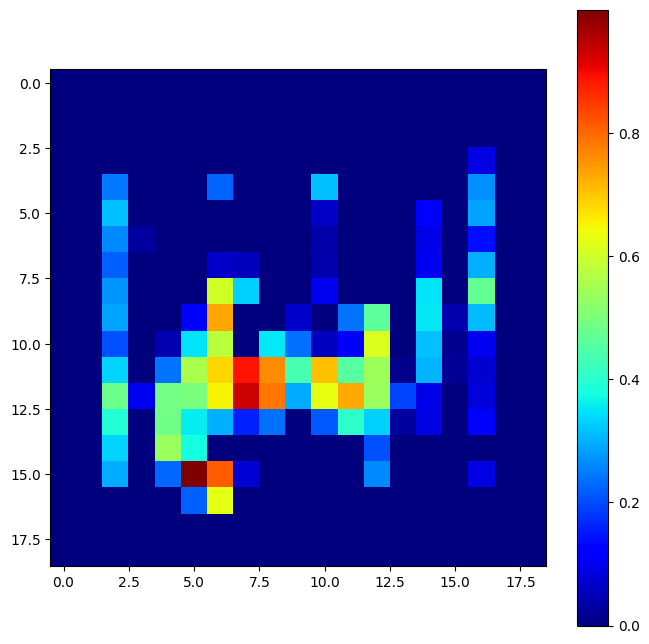

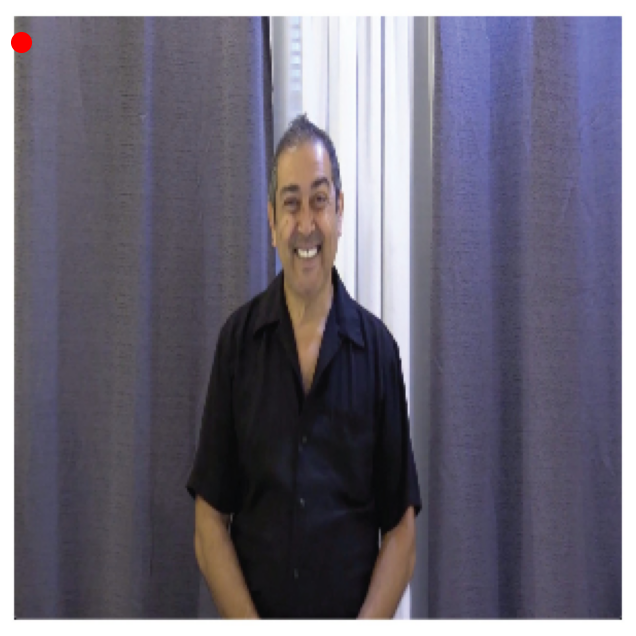

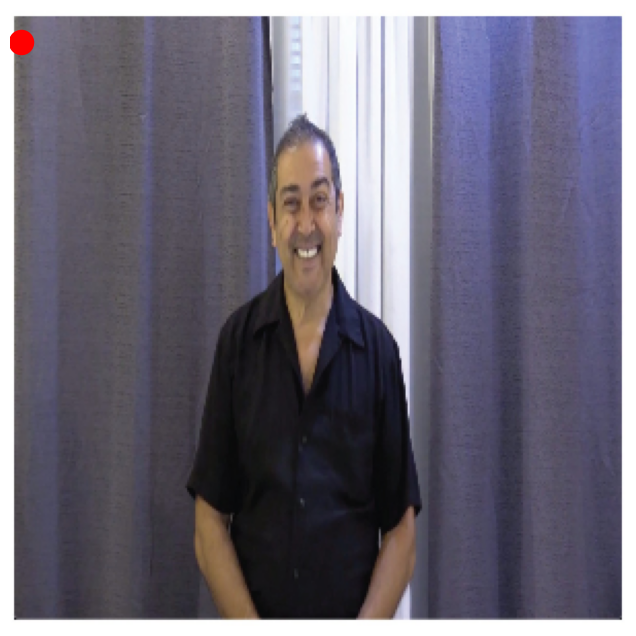

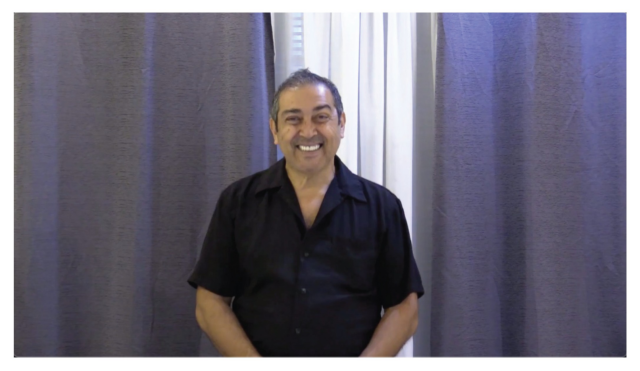

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/drive/MyDrive/VeritasAI/gradcam_results/pnas.2110013119fig01.jpg")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if f.endswith(".zip"):
            print(os.path.join(root, f))

/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Done")

Done


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


In [ ]:
for root, dirs, files in os.walk("/content/dataset"):
    if "real" in root.lower() or "fake" in root.lower():
        print(root)

/content/dataset/real-vs-fake
/content/dataset/real-vs-fake/valid
/content/dataset/real-vs-fake/valid/fake
/content/dataset/real-vs-fake/valid/real
/content/dataset/real-vs-fake/test
/content/dataset/real-vs-fake/test/fake
/content/dataset/real-vs-fake/test/real
/content/dataset/real-vs-fake/train
/content/dataset/real-vs-fake/train/fake
/content/dataset/real-vs-fake/train/real


In [ ]:
import os
import random

real_imgs = []
fake_imgs = []

for root, dirs, files in os.walk("/content/dataset"):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):

            full = os.path.join(root, f)

            if "/real/" in full.lower():
                real_imgs.append(full)

            elif "/fake/" in full.lower():
                fake_imgs.append(full)

print("REAL:", random.choice(real_imgs))
print("FAKE:", random.choice(fake_imgs))

REAL: /content/dataset/real-vs-fake/valid/real/33442.jpg
FAKE: /content/dataset/real-vs-fake/test/fake/QCQIQ94Z4T.jpg


[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -7.6249176e-05
grads max : 5.1525752e-05
grads mean: -1.4999613e-07

===== POOLED GRADS =====
pooled min : -3.64054e-06
pooled max : 6.7950555e-06
pooled mean: -1.4999613e-07

===== RAW HEATMAP =====
raw min : -4.9598693e-05
raw max : 1.0302031e-05
raw mean: -9.636927e-06
Probability = 0.999631404876709


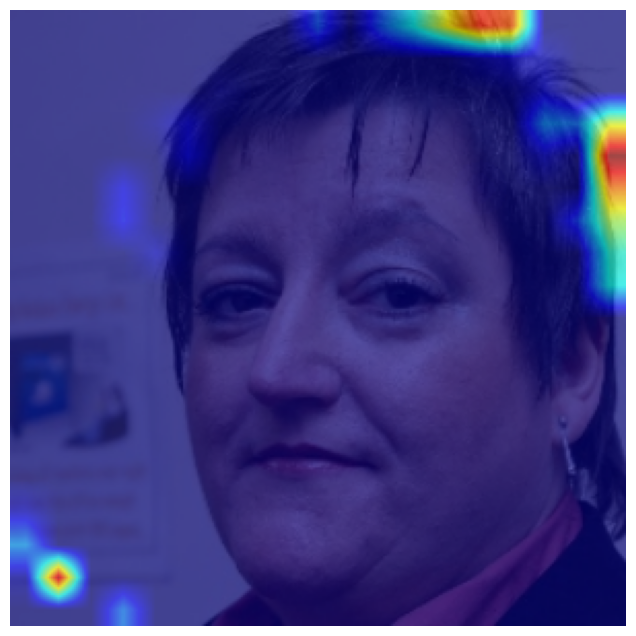

In [ ]:
test_image = "/content/dataset/real-vs-fake/valid/real/33442.jpg"

img_tensor, img_orig = preprocess_image(test_image)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block12_sepconv2_act"
)

print("Probability =", prob)

overlay = overlay_heatmap(
    heatmap,
    img_orig,
    alpha=0.65
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

max_pos = np.unravel_index(np.argmax(heatmap), heatmap.shape)

print("Max position =", max_pos)
print("Max value =", heatmap[max_pos])

Max position = (np.int64(4), np.int64(18))
Max value = 0.9990303


[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -0.012250645
grads max : 0.016281318
grads mean: -3.0508705e-05

===== POOLED GRADS =====
pooled min : -0.00079590676
pooled max : 0.0022650294
pooled mean: -3.0508707e-05

===== RAW HEATMAP =====
raw min : -0.009470942
raw max : 0.0013142494
raw mean: -0.0028298285
Probability = 0.1448388248682022


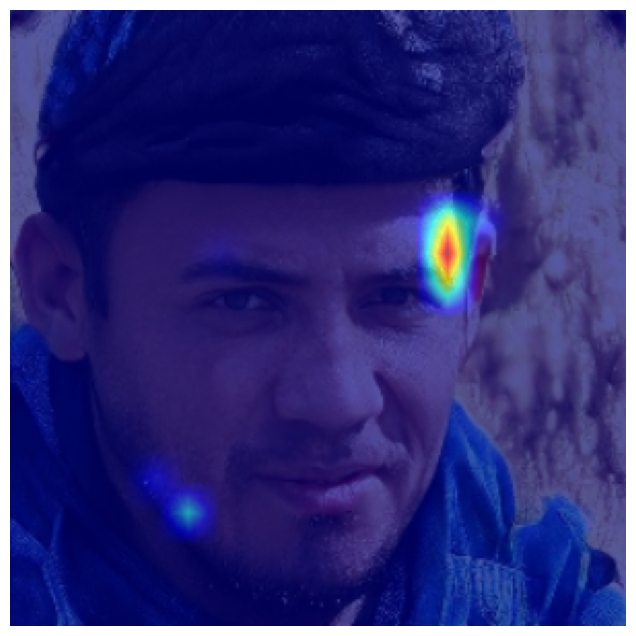

In [ ]:
test_image = "/content/dataset/real-vs-fake/test/fake/QCQIQ94Z4T.jpg"

img_tensor, img_orig = preprocess_image(test_image)

heatmap, prob = compute_gradcam(
    model,
    img_tensor,
    "block12_sepconv2_act"
)

print("Probability =", prob)

overlay = overlay_heatmap(
    heatmap,
    img_orig,
    alpha=0.65
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

max_pos = np.unravel_index(np.argmax(heatmap), heatmap.shape)

print("Max position =", max_pos)
print("Max value =", heatmap[max_pos])

Max position = (np.int64(7), np.int64(13))
Max value = 0.9999924


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt

In [3]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/VeritasAI/models/veritas_xception_v2_finetuned.keras"
)

print("Model loaded successfully")

Model loaded successfully


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/VeritasAI/dataset/real-vs-fake.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted")

Dataset extracted


In [6]:
"""
Grad-CAM Implementation for Veritas AI (Xception-based Deepfake Detector)
=========================================================================
Model Architecture: Sequential > Xception (ImageNet) > GAP > Dropout(0.5)
                    > Dense(128, relu) > Dropout(0.3) > Dense(1, sigmoid)
Input Size: 299x299
Output: Binary classification (Real vs Fake)

Usage:
    python gradcam_veritas.py --image path/to/image.jpg
    python gradcam_veritas.py --image path/to/image.jpg --model path/to/model.keras
    python gradcam_veritas.py --image path/to/image.jpg --threshold 0.5 --output result.jpg
"""

import argparse
import sys
import numpy as np
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")           # headless-safe backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path


# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
IMG_SIZE        = (299, 299)
DEFAULT_MODEL   = "veritas_xception_v2_finetuned.keras"

# ── The last convolutional layer inside Xception ──────────────────────────────
# Xception's final conv block is "block14_sepconv2_act".
# Inside a Sequential wrapper the Xception sub-model is accessed via
# model.layers[0], so the full path becomes:
#   model → Sequential.layers[0] (Xception) → "block14_sepconv2_act"
# Run `python gradcam_veritas.py --list-layers` to confirm on your saved model.
LAST_CONV_LAYER = "block12_sepconv2_act"


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def load_model(model_path: str) -> tf.keras.Model:
    path = Path(model_path)
    if not path.exists():
        sys.exit(f"[ERROR] Model file not found: {model_path}")
    print(f"[INFO] Loading model from {model_path} …")
    model = tf.keras.models.load_model(str(path))
    print(f"[INFO] Model loaded — {len(model.layers)} top-level layers")
    return model


def preprocess_image(image_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (preprocessed_tensor [1,H,W,3], original_uint8 [H,W,3])."""
    path = Path(image_path)
    if not path.exists():
        sys.exit(f"[ERROR] Image file not found: {image_path}")

    img_bgr  = cv2.imread(str(path))
    if img_bgr is None:
        sys.exit(f"[ERROR] Could not decode image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_rgb, IMG_SIZE)          # keep for overlay

    # Xception expects float inputs preprocessed via its own function
    img_f    = tf.keras.applications.xception.preprocess_input(
                   img_orig.astype(np.float32).copy()
               )
    img_f    = np.expand_dims(img_f, axis=0)          # [1, 299, 299, 3]
    return img_f, img_orig


def find_last_conv_layer(model: tf.keras.Model, requested: str) -> tuple[tf.keras.Model, str]:
    """
    Locate the target conv layer inside the (potentially nested) model.

    Priority:
      1. Direct layer in top-level Sequential
      2. Layer inside Sequential.layers[0] (the Xception sub-model)
      3. Auto-detect: last Conv2D / SeparableConv2D in the Xception sub-model
    """
    # ── Case 1: layer exists at top level ─────────────────────────────────────
    try:
        model.get_layer(requested)
        print(f"[INFO] Conv target found at top level: '{requested}'")
        return model, requested
    except ValueError:
        pass

    # ── Case 2: nested Xception sub-model ─────────────────────────────────────
    xception_sub = model.layers[0]                    # first layer of Sequential
    try:
        xception_sub.get_layer(requested)
        print(f"[INFO] Conv target found in sub-model (layers[0]): '{requested}'")
        return xception_sub, requested
    except ValueError:
        pass

    # ── Case 3: auto-detect last convolutional activation ─────────────────────
    print(f"[WARN] Layer '{requested}' not found — auto-detecting last conv layer …")
    conv_candidates = [
        l.name for l in xception_sub.layers
        if isinstance(l, (tf.keras.layers.Conv2D,
                          tf.keras.layers.SeparableConv2D,
                          tf.keras.layers.DepthwiseConv2D,
                          tf.keras.layers.Activation))
           and hasattr(l, "output_shape")
           and len(l.output_shape) == 4    # must be spatial (4-D)
    ]
    if not conv_candidates:
        sys.exit("[ERROR] Could not find any convolutional layer automatically.")

    auto = conv_candidates[-1]
    print(f"[INFO] Auto-selected last conv layer: '{auto}'")
    return xception_sub, auto


def list_layers(model: tf.keras.Model) -> None:
    """Print every layer and its output shape for manual inspection."""
    print("\n── Top-level Sequential layers ──────────────────────────────")
    for i, l in enumerate(model.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:2d}] {l.name:45s}  {str(shape)}")

    print("\n── Xception sub-model (layers[0]) layers ────────────────────")
    xception_sub = model.layers[0]
    for i, l in enumerate(xception_sub.layers):
        try:
            shape = l.output_shape
        except AttributeError:
            shape = "?"
        print(f"  [{i:3d}] {l.name:45s}  {str(shape)}")
    print()


# ─────────────────────────────────────────────
# GRAD-CAM CORE
# ─────────────────────────────────────────────

def compute_gradcam(
    model:           tf.keras.Model,
    img_tensor:      np.ndarray,        # [1, H, W, 3]
    last_conv_layer: str,
) -> tuple[np.ndarray, float]:
    """
    Returns
    -------
    heatmap : np.ndarray  float32 in [0, 1], shape (h, w)
    prob    : float       sigmoid output (probability of REAL)
    """
    # ── Locate the conv layer (top-level or sub-model) ─────────────────────
    grad_model_src, layer_name = find_last_conv_layer(model, last_conv_layer)

    # ── Build a sub-graph: input → [conv_output, final_prediction] ─────────
    conv_layer   = grad_model_src.get_layer(layer_name)
    grad_model   = tf.keras.Model(
        inputs  = grad_model_src.input,
        outputs = [conv_layer.output, grad_model_src.output]
    )

    # ── If target is in the sub-model, wrap with the full Sequential ────────
    use_full_model = (grad_model_src is not model)

    with tf.GradientTape() as tape:
        img_tf          = tf.cast(img_tensor, tf.float32)
        if use_full_model:
            conv_out, sub_out = grad_model(img_tf, training=False)
            # Pass sub_model output through remaining Sequential layers
            x = sub_out
            for layer in model.layers[1:]:
                x = layer(x, training=False)
            preds = x
        else:
            conv_out, preds = grad_model(img_tf, training=False)

        # Binary classifier → single output neuron
        class_channel = preds[:, 0]

    # Gradients of the class score w.r.t. the convolutional feature maps
    grads = tape.gradient(class_channel, conv_out)

    print("\n===== GRADIENT DEBUG =====")
    print("grads is None:", grads is None)

    if grads is None:
        raise RuntimeError(
            f"No gradients found for layer '{layer_name}'. "
            "Check that the selected layer is connected to the output."
    )

    print("grads min :", tf.reduce_min(grads).numpy())
    print("grads max :", tf.reduce_max(grads).numpy())
    print("grads mean:", tf.reduce_mean(grads).numpy())

    # Pool gradients over spatial dimensions → importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    print("\n===== POOLED GRADS =====")
    print("pooled min :", tf.reduce_min(pooled_grads).numpy())
    print("pooled max :", tf.reduce_max(pooled_grads).numpy())
    print("pooled mean:", tf.reduce_mean(pooled_grads).numpy())    # [C]

    # Weight feature maps by channel importance
    conv_out     = conv_out[0]                              # [h, w, C]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis] # [h, w, 1]
    heatmap = tf.squeeze(heatmap)

    print("\n===== RAW HEATMAP =====")
    print("raw min :", tf.reduce_min(heatmap).numpy())
    print("raw max :", tf.reduce_max(heatmap).numpy())
    print("raw mean:", tf.reduce_mean(heatmap).numpy())                      # [h, w]

    # ReLU + normalise to [0, 1]
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap      = heatmap.numpy().astype(np.float32)

    prob         = float(preds[0, 0].numpy())
    return heatmap, prob


# ─────────────────────────────────────────────
# OVERLAY
# ─────────────────────────────────────────────

def overlay_heatmap(
    heatmap:    np.ndarray,   # float32 [0,1]
    orig_img:   np.ndarray,   # uint8 RGB [H, W, 3]
    alpha:      float = 0.45,
    colormap:   int   = cv2.COLORMAP_JET,
) -> np.ndarray:
    """Resize heatmap → apply colormap → blend with original (RGB uint8)."""
    h, w    = orig_img.shape[:2]
    heat_u8 = np.uint8(255 * heatmap)
    heat_u8 = cv2.resize(heat_u8, (w, h))
    colored = cv2.applyColorMap(heat_u8, colormap)          # BGR
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)      # → RGB
    blended = cv2.addWeighted(orig_img, 1 - alpha, colored, alpha, 0)
    return blended


# ─────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────

def build_visualization(
    orig_img:    np.ndarray,
    blended:     np.ndarray,
    heatmap:     np.ndarray,
    prob:        float,
    threshold:   float,
    image_path:  str,
    output_path: str,
) -> None:
    label       = "REAL" if prob >= threshold else "FAKE"
    conf        = prob if label == "REAL" else 1 - prob
    label_color = "#2ecc71" if label == "REAL" else "#e74c3c"

    fig = plt.figure(figsize=(16, 6), facecolor="#111111")
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.05)

    panels = [
        (orig_img,   "Original",        "gray"),
        (heatmap,    "Grad-CAM Heatmap", "jet"),
        (blended,    "Overlay",          "gray"),
    ]

    for idx, (data, title, cmap) in enumerate(panels):
        ax = fig.add_subplot(gs[0, idx])
        ax.imshow(data, cmap=(cmap if data.ndim == 2 else None))
        ax.set_title(title, color="white", fontsize=11, pad=6)
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    # ── Verdict panel ─────────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.set_facecolor("#1a1a1a")
    ax4.axis("off")

    ax4.text(0.5, 0.80, "VERDICT", transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa",
             fontsize=10, fontweight="bold")

    ax4.text(0.5, 0.58, label, transform=ax4.transAxes,
             ha="center", va="center", color=label_color,
             fontsize=32, fontweight="bold")

    bar_bg  = plt.Rectangle((0.1, 0.40), 0.80, 0.07,
                              transform=ax4.transAxes,
                              color="#333333", zorder=2)
    bar_fg  = plt.Rectangle((0.1, 0.40), 0.80 * prob, 0.07,
                              transform=ax4.transAxes,
                              color=label_color, zorder=3)
    ax4.add_patch(bar_bg)
    ax4.add_patch(bar_fg)

    ax4.text(0.5, 0.34, f"Real probability: {prob:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#cccccc", fontsize=9)

    ax4.text(0.5, 0.24, f"Confidence: {conf:.1%}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#aaaaaa", fontsize=9)

    ax4.text(0.5, 0.14, f"Threshold: {threshold:.2f}",
             transform=ax4.transAxes,
             ha="center", va="center", color="#666666", fontsize=8)

    fname = Path(image_path).name
    ax4.text(0.5, 0.05, fname, transform=ax4.transAxes,
             ha="center", va="center", color="#555555", fontsize=7,
             style="italic")

    fig.suptitle("Veritas AI — Deepfake Detection  |  Grad-CAM Explanation",
                 color="white", fontsize=13, y=1.01)

    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"[INFO] Visualization saved → {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run(args: argparse.Namespace) -> None:
    model   = load_model(args.model)

    if args.list_layers:
        list_layers(model)
        sys.exit(0)

    print(f"[INFO] Processing image: {args.image}")
    img_tensor, img_orig = preprocess_image(args.image)

    print(f"[INFO] Running Grad-CAM on layer: '{args.layer}'")
    heatmap, prob = compute_gradcam(model, img_tensor, args.layer)

    label = "REAL" if prob >= args.threshold else "FAKE"
    print(f"\n{'─'*40}")
    print(f"  Prediction : {label}")
    print(f"  Real prob  : {prob:.4f}  ({prob:.1%})")
    print(f"  Threshold  : {args.threshold}")
    print(f"{'─'*40}\n")

    blended = overlay_heatmap(heatmap, img_orig, alpha=args.alpha)

    out_path = args.output or (
        Path(args.image).stem + "_gradcam.jpg"
    )
    build_visualization(
        orig_img    = img_orig,
        blended     = blended,
        heatmap     = heatmap,
        prob        = prob,
        threshold   = args.threshold,
        image_path  = args.image,
        output_path = str(out_path),
    )


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(
        description="Grad-CAM explainability for Veritas AI deepfake detector"
    )
    p.add_argument("--image",       type=str, default=None,
                   help="Path to input image")
    p.add_argument("--model",       type=str, default=DEFAULT_MODEL,
                   help=f"Path to .keras model (default: {DEFAULT_MODEL})")
    p.add_argument("--layer",       type=str, default=LAST_CONV_LAYER,
                   help=f"Target conv layer name (default: {LAST_CONV_LAYER})")
    p.add_argument("--threshold",   type=float, default=0.5,
                   help="Decision threshold for FAKE (default: 0.5)")
    p.add_argument("--alpha",       type=float, default=0.45,
                   help="Heatmap overlay opacity, 0–1 (default: 0.45)")
    p.add_argument("--output",      type=str, default=None,
                   help="Output file path (default: <image_stem>_gradcam.jpg)")
    p.add_argument("--list-layers", action="store_true",
                   help="Print all layer names and exit (for layer discovery)")
    return p.parse_args()


# if __name__ == "__main__":
#     args = parse_args()
#     if not args.list_layers and args.image is None:
#         print("[ERROR] --image is required unless --list-layers is specified.")
#         print("Usage:  python gradcam_veritas.py --image face.jpg")
#         sys.exit(1)
#     run(args)

In [7]:
import os
import random

real_imgs = []
fake_imgs = []

for root, dirs, files in os.walk("/content/dataset"):
    for f in files:
        if f.lower().endswith((".jpg",".jpeg",".png")):

            path = os.path.join(root, f)

            if "/real/" in path.lower():
                real_imgs.append(path)

            elif "/fake/" in path.lower():
                fake_imgs.append(path)

random.seed(42)

real_sample = random.sample(real_imgs, 10)
fake_sample = random.sample(fake_imgs, 10)

print("===== REAL =====")
for p in real_sample:
    print(p)

print("\n===== FAKE =====")
for p in fake_sample:
    print(p)

===== REAL =====
/content/dataset/real-vs-fake/train/real/64974.jpg
/content/dataset/real-vs-fake/train/real/12551.jpg
/content/dataset/real-vs-fake/train/real/51991.jpg
/content/dataset/real-vs-fake/train/real/27703.jpg
/content/dataset/real-vs-fake/train/real/23647.jpg
/content/dataset/real-vs-fake/train/real/36457.jpg
/content/dataset/real-vs-fake/train/real/56537.jpg
/content/dataset/real-vs-fake/train/real/32292.jpg
/content/dataset/real-vs-fake/valid/real/42651.jpg
/content/dataset/real-vs-fake/train/real/46958.jpg

===== FAKE =====
/content/dataset/real-vs-fake/train/fake/S563ZIIFBV.jpg
/content/dataset/real-vs-fake/train/fake/9EXNWTNZM7.jpg
/content/dataset/real-vs-fake/train/fake/D15P6HBBTF.jpg
/content/dataset/real-vs-fake/train/fake/AOBLTM5IRD.jpg
/content/dataset/real-vs-fake/test/fake/4ULHR7H9YH.jpg
/content/dataset/real-vs-fake/train/fake/ZUTPB6DF6P.jpg
/content/dataset/real-vs-fake/train/fake/0FRFD22RWM.jpg
/content/dataset/real-vs-fake/valid/fake/O2NY85VW73.jpg
/content

In [8]:
from pathlib import Path
from PIL import Image
import os

audit_images = real_sample + fake_sample

output_dir = "/content/drive/MyDrive/VeritasAI/gradcam_audit_20"
os.makedirs(output_dir, exist_ok=True)

for idx, test_image in enumerate(audit_images):

    try:
        img_tensor, img_orig = preprocess_image(test_image)

        heatmap, prob = compute_gradcam(
            model,
            img_tensor,
            "block12_sepconv2_act"
        )

        overlay = overlay_heatmap(
            heatmap,
            img_orig,
            alpha=0.65
        )

        fname = Path(test_image).stem

        save_path = os.path.join(
            output_dir,
            f"{idx+1}_{fname}_p{prob:.3f}.jpg"
        )

        Image.fromarray(overlay).save(save_path)

        print(f"Saved {idx+1}/20")

    except Exception as e:
        print("ERROR:", test_image)
        print(e)

print("\nDONE")
print(output_dir)

[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -0.0020015014
grads max : 0.0029033495
grads mean: -5.480204e-06

===== POOLED GRADS =====
pooled min : -0.00011686307
pooled max : 0.00013092557
pooled mean: -5.480204e-06

===== RAW HEATMAP =====
raw min : -0.0019774542
raw max : 0.00015837175
raw mean: -0.00053890684
Saved 1/20
[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -1.473152e-08
grads max : 1.1561271e-08
grads mean: -4.6376293e-12

===== POOLED GRADS =====
pooled min : -5.91486e-10
pooled max : 1.2585256e-09
pooled mean: -4.63763e-12

===== RAW HEATMAP =====
raw min : -5.555796e-09
raw max : 5.9365766e-09
raw mean: -7.144139e-10
Saved 2/20
[INFO] Conv target found in sub-model (layers[0]): 'block12_sepconv2_act'

===== GRADIENT DEBUG =====
grads is None: False
grads min : -1.0242463e-06
grads max : 6.7943

In [9]:
import os

files = sorted(os.listdir("/content/drive/MyDrive/VeritasAI/gradcam_audit_20"))

print("Files generated:", len(files))

for f in files:
    print(f)

Files generated: 20
10_46958_p1.000.jpg
11_S563ZIIFBV_p0.002.jpg
12_9EXNWTNZM7_p0.001.jpg
13_D15P6HBBTF_p0.001.jpg
14_AOBLTM5IRD_p0.006.jpg
15_4ULHR7H9YH_p0.536.jpg
16_ZUTPB6DF6P_p0.006.jpg
17_0FRFD22RWM_p0.826.jpg
18_O2NY85VW73_p0.022.jpg
19_LSNIFA82X1_p0.274.jpg
1_64974_p0.961.jpg
20_Q78PHZB6IX_p0.160.jpg
2_12551_p1.000.jpg
3_51991_p1.000.jpg
4_27703_p0.771.jpg
5_23647_p1.000.jpg
6_36457_p1.000.jpg
7_56537_p0.998.jpg
8_32292_p1.000.jpg
9_42651_p1.000.jpg


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,529,389 (150.79 MB)

 Trainable params: 9,202,753 (35.11 MB)

 Non-trainable params: 11,921,128 (45.48 MB)

 Optimizer params: 18,405,508 (70.21 MB)

In [11]:
print(model.metrics_names)

['loss', 'compile_metrics']


In [12]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

test_ds = image_dataset_from_directory(
    "/content/dataset/real-vs-fake/test",
    image_size=(299,299),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(
    lambda x,y: (
        tf.keras.applications.xception.preprocess_input(
            tf.cast(x, tf.float32)
        ),
        y
    )
)

Found 20000 files belonging to 2 classes.


In [13]:
results = model.evaluate(test_ds, verbose=1)

print(results)

625/625 ━━━━━━━━━━━━━━━━━━━━ 238s 306ms/step - accuracy: 0.9603 - loss: 0.1001
[0.1000562533736229, 0.9603000283241272]
